In [2]:
!pip install git+https://github.com/openai/CLIP.git


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-_tlyh85p
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-_tlyh85p
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=fab12b6cf65424a09f4a128d96c4ccb8df81b8e4fa4399f92eaf8aa0eda603cf
  Stored in directory: /tmp/pip-ephem-wheel-cache-b0zwrbq0/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [3]:
import torch
import clip
import numpy as np
import torch.nn.functional as F

from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import os
print(os.listdir("/content/drive/MyDrive"))


['Colab Notebooks', 'mtech', 'best_vit_hcc.pth']


In [6]:
base_path = "/content/drive/MyDrive"


In [7]:
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".zip"):
            print(os.path.join(root, file))


/content/drive/MyDrive/mtech/Test-20260213T111402Z-1-001.zip
/content/drive/MyDrive/mtech/Validation-20260213T111425Z-1-001.zip
/content/drive/MyDrive/mtech/Training-20260213T113205Z-1-001.zip


In [8]:
print(os.listdir("/content/drive/MyDrive/mtech"))


['Test-20260213T111402Z-1-001.zip', 'Validation-20260213T111425Z-1-001.zip', 'Training-20260213T113205Z-1-001.zip']


In [9]:
import zipfile

base_path = "/content/drive/MyDrive/mtech"
extract_path = "/content/hcc_dataset"

os.makedirs(extract_path, exist_ok=True)

for file in os.listdir(base_path):
    if file.endswith(".zip"):
        print("Extracting:", file)
        with zipfile.ZipFile(os.path.join(base_path, file), 'r') as zip_ref:
            zip_ref.extractall(extract_path)

print("Extraction complete")


Extracting: Test-20260213T111402Z-1-001.zip
Extracting: Validation-20260213T111425Z-1-001.zip
Extracting: Training-20260213T113205Z-1-001.zip
Extraction complete


In [10]:
print(os.listdir("/content/hcc_dataset"))


['Test', 'Training', 'Validation']


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import clip

device = "cuda" if torch.cuda.is_available() else "cpu"

model_clip, preprocess = clip.load("ViT-B/32", device=device)
model_clip.train()


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 119MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [12]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_path = "/content/hcc_dataset/Training"
val_path = "/content/hcc_dataset/Validation"
test_path = "/content/hcc_dataset/Test"

train_dataset = datasets.ImageFolder(train_path, transform=preprocess)
val_dataset = datasets.ImageFolder(val_path, transform=preprocess)
test_dataset = datasets.ImageFolder(test_path, transform=preprocess)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [13]:
class CLIPFineTune(nn.Module):
    def __init__(self, clip_model, num_classes=4):
        super().__init__()
        self.clip_model = clip_model
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.clip_model.encode_image(x)
        features = features.float()
        features = features / features.norm(dim=-1, keepdim=True)
        return self.classifier(features)


In [17]:
model_clip, preprocess = clip.load("ViT-B/32", device=device)

# Convert to float32 to prevent fp16 overflow
model_clip = model_clip.float()


In [18]:
model_ft = CLIPFineTune(model_clip).to(device)


In [19]:
optimizer = torch.optim.Adam([
    {"params": model_ft.clip_model.parameters(), "lr": 1e-6},
    {"params": model_ft.classifier.parameters(), "lr": 1e-4}
])

criterion = nn.CrossEntropyLoss()


In [20]:
epochs = 15

for epoch in range(epochs):
    model_ft.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_ft(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {running_loss:.4f} "
          f"Train Acc: {train_acc:.2f}%")


Epoch [1/15] Loss: 184.7036 Train Acc: 78.38%
Epoch [2/15] Loss: 127.4010 Train Acc: 92.43%
Epoch [3/15] Loss: 91.9795 Train Acc: 98.55%
Epoch [4/15] Loss: 68.1423 Train Acc: 99.22%
Epoch [5/15] Loss: 50.8375 Train Acc: 100.00%
Epoch [6/15] Loss: 39.4304 Train Acc: 100.00%
Epoch [7/15] Loss: 31.3437 Train Acc: 100.00%
Epoch [8/15] Loss: 25.3633 Train Acc: 100.00%
Epoch [9/15] Loss: 20.8442 Train Acc: 100.00%
Epoch [10/15] Loss: 17.3682 Train Acc: 100.00%
Epoch [11/15] Loss: 14.6384 Train Acc: 100.00%
Epoch [12/15] Loss: 12.4643 Train Acc: 100.00%
Epoch [13/15] Loss: 10.7051 Train Acc: 100.00%
Epoch [14/15] Loss: 9.2658 Train Acc: 100.00%
Epoch [15/15] Loss: 8.0746 Train Acc: 100.00%


In [21]:
model_ft.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_ft(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)


Validation Accuracy: 95.0


In [22]:
model_ft.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_ft(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)


Test Accuracy: 92.85714285714286


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import clip

from torchvision import datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix


In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model = clip_model.float()


In [25]:
train_path = "/content/hcc_dataset/Training"
val_path = "/content/hcc_dataset/Validation"

train_dataset = datasets.ImageFolder(train_path, transform=preprocess)
val_dataset = datasets.ImageFolder(val_path, transform=preprocess)

from torch.utils.data import ConcatDataset
full_dataset = ConcatDataset([train_dataset, val_dataset])


In [26]:
all_labels = []

for _, label in full_dataset:
    all_labels.append(label)

all_labels = np.array(all_labels)


In [27]:
class CLIPFineTune(nn.Module):
    def __init__(self, clip_model, num_classes=4):
        super().__init__()
        self.clip_model = clip_model
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.clip_model.encode_image(x)
        features = features.float()
        return self.classifier(features)


In [28]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

fold_accuracies = []
fold_aucs = []
fold_conf_matrices = []


In [29]:
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):
    print(f"\n===== Fold {fold+1} =====")

    train_subset = Subset(full_dataset, train_idx)
    val_subset = Subset(full_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)

    # Reload fresh CLIP each fold
    clip_model, _ = clip.load("ViT-B/32", device=device)
    clip_model = clip_model.float()

    model = CLIPFineTune(clip_model).to(device)

    optimizer = torch.optim.Adam([
        {"params": model.clip_model.parameters(), "lr": 5e-7},
        {"params": model.classifier.parameters(), "lr": 1e-4}
    ])

    criterion = nn.CrossEntropyLoss()

    # ---- Train 8 epochs (enough) ----
    epochs = 8
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    # ---- Validation Evaluation ----
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_fold_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_fold_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = 100 * correct / total
    fold_accuracies.append(acc)

    auc = roc_auc_score(all_fold_labels, all_probs, multi_class='ovr')
    fold_aucs.append(auc)

    cm = confusion_matrix(all_fold_labels, all_preds)
    fold_conf_matrices.append(cm)

    print(f"Fold Accuracy: {acc:.2f}%")
    print(f"Fold ROC-AUC: {auc:.4f}")



===== Fold 1 =====
Fold Accuracy: 94.70%
Fold ROC-AUC: 0.9916

===== Fold 2 =====
Fold Accuracy: 96.18%
Fold ROC-AUC: 0.9964

===== Fold 3 =====
Fold Accuracy: 94.49%
Fold ROC-AUC: 0.9940


In [30]:
fold_accuracies = np.array(fold_accuracies)
fold_aucs = np.array(fold_aucs)

print("\n===== 3-Fold Cross-Validation Results =====")
print(f"Accuracy: {fold_accuracies.mean():.2f}% ± {fold_accuracies.std():.2f}")
print(f"ROC-AUC: {fold_aucs.mean():.4f} ± {fold_aucs.std():.4f}")



===== 3-Fold Cross-Validation Results =====
Accuracy: 95.12% ± 0.75
ROC-AUC: 0.9940 ± 0.0020


In [32]:
import numpy as np
from scipy import stats

vit_acc = np.array([95.22, 94.70, 93.82, 93.29, 90.09])


clip_acc = np.array([94.7, 96.18, 94.49])


In [33]:
t_stat, p_value = stats.ttest_ind(clip_acc, vit_acc, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: 1.6276533584007133
p-value: 0.15593491240259058


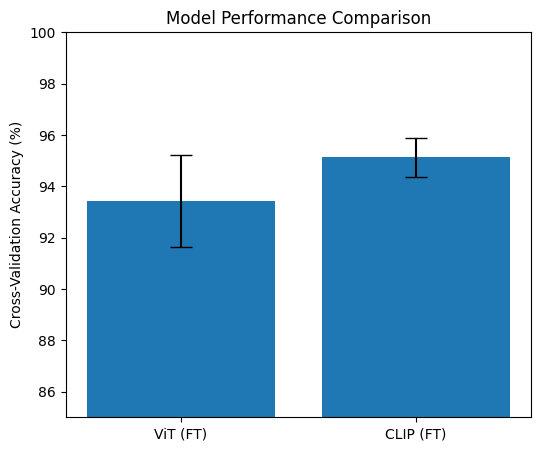

In [34]:
import matplotlib.pyplot as plt

models = ["ViT (FT)", "CLIP (FT)"]
mean_acc = [vit_acc.mean(), clip_acc.mean()]
std_acc = [vit_acc.std(), clip_acc.std()]

plt.figure(figsize=(6,5))
plt.bar(models, mean_acc, yerr=std_acc, capsize=8)

plt.ylabel("Cross-Validation Accuracy (%)")
plt.title("Model Performance Comparison")
plt.ylim(85, 100)
plt.show()


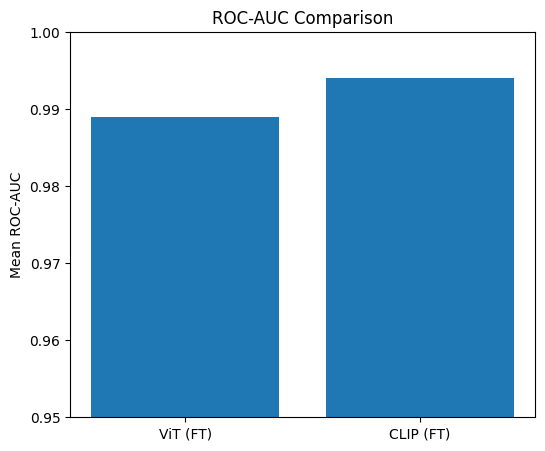

In [35]:
vit_auc_mean = 0.989  # replace with your real value
clip_auc_mean = 0.994

models = ["ViT (FT)", "CLIP (FT)"]
auc_values = [vit_auc_mean, clip_auc_mean]

plt.figure(figsize=(6,5))
plt.bar(models, auc_values)

plt.ylabel("Mean ROC-AUC")
plt.title("ROC-AUC Comparison")
plt.ylim(0.95, 1.0)
plt.show()


In [39]:
import torch
import torch.nn.functional as F
import numpy as np

model_ft.eval()

clip_preds = []
clip_labels = []
clip_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_ft(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(probs, 1)

        clip_preds.extend(predicted.cpu().numpy())
        clip_labels.extend(labels.cpu().numpy())
        clip_probs.extend(probs.cpu().numpy())

clip_preds = np.array(clip_preds)
clip_labels = np.array(clip_labels)
clip_probs = np.array(clip_probs)

print("Saved predictions and probabilities.")


Saved predictions and probabilities.


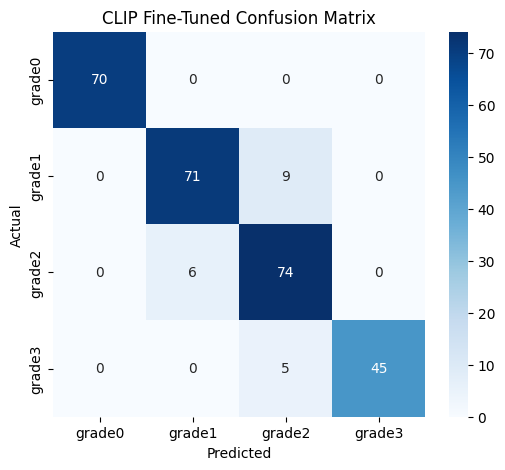

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ["grade0", "grade1", "grade2", "grade3"]

clip_cm = confusion_matrix(clip_labels, clip_preds)

plt.figure(figsize=(6,5))
sns.heatmap(clip_cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("CLIP Fine-Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


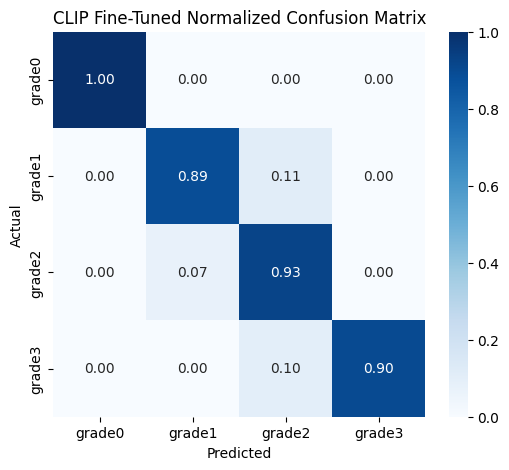

In [41]:
clip_cm_norm = clip_cm.astype('float') / clip_cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(clip_cm_norm,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("CLIP Fine-Tuned Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


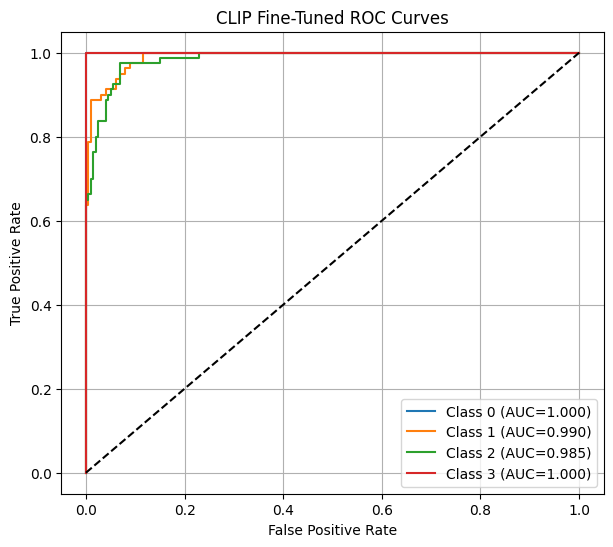

In [42]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = 4
clip_labels_bin = label_binarize(clip_labels, classes=[0,1,2,3])

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(clip_labels_bin[:, i], clip_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CLIP Fine-Tuned ROC Curves")
plt.legend()
plt.grid()
plt.show()


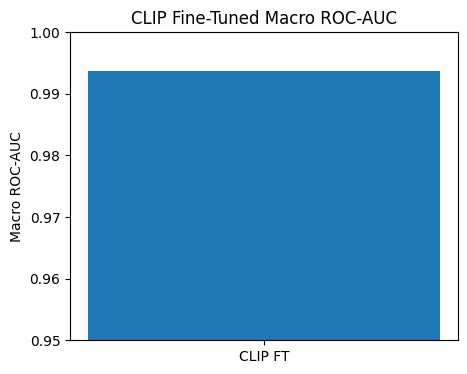

Macro ROC-AUC: 0.993703125


In [43]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(clip_labels, clip_probs, multi_class='ovr')

plt.figure(figsize=(5,4))
plt.bar(["CLIP FT"], [macro_auc])
plt.ylabel("Macro ROC-AUC")
plt.ylim(0.95, 1.0)
plt.title("CLIP Fine-Tuned Macro ROC-AUC")
plt.show()

print("Macro ROC-AUC:", macro_auc)
